# NVIDIA: historical analysis and first forecast

Your existing notebook, repaired and extended to the next learning step.

**Run:** Jupyter → Kernel → Restart Kernel and Run All Cells.

**Requirements:** pandas and matplotlib. If either is missing, install it into your notebook kernel environment before running. Automatic package installation has been removed from normal execution.

The notebook includes a snapshot of your uploaded CSV so it runs without your Mac's original file path. To use a different CSV, set `CSV_PATH` in section 2. Existing reported ratios are preserved; calculated ratios are separate.

**Scope:** historical table, two charts and an illustrative FY2027 revenue/operating-income forecast. FCFF and DCF remain pending because the required dated valuation inputs are not yet verified. This is not the completed AI platform.

## 1. Import libraries

In [1]:
from pathlib import Path
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.options.display.float_format = "{:,.2f}".format

## 2. Load your data
Leave `CSV_PATH = None` to use the exact uploaded CSV snapshot. To use your own file, set it to a path such as `Path("DATA/NVIDIA_Annual_Report_Last_3_Years-v2.csv")` relative to the notebook working directory.

The snapshot contains rounded USD-billion amounts. Its generic source links and reported ratios still need the source audit described in your guide. Embedding the CSV makes it portable; it does not turn it into independently verified data.

In [2]:
CSV_PATH = None

EMBEDDED_CSV = 'Fiscal Year,Total Revenue ($B),YoY Revenue Growth (%),Gross Margin (%),Operating Income ($B),Operating Margin (%),Net Income ($B),YoY Net Income Growth (%),Diluted EPS ($ Split-Adjusted),Source Link\nFY 2024 (Ended Jan 2024),60.92,126.0,72.7,32.97,54.1,29.76,581.0,1.19,https://investor.nvidia.com/financial-info/sec-filings/default.aspx\nFY 2025 (Ended Jan 2025),130.5,114.0,75.0,81.45,62.4,72.88,145.0,2.94,https://investor.nvidia.com/financial-info/sec-filings/default.aspx\nFY 2026 (Ended Jan 2026),215.94,65.4,71.1,130.39,60.4,120.07,64.7,4.9,https://investor.nvidia.com/financial-info/sec-filings/default.aspx\n'

if CSV_PATH is None:
    raw_dataset = pd.read_csv(StringIO(EMBEDDED_CSV))
    print("Loaded your uploaded NVIDIA CSV snapshot (USD billions).")
else:
    csv_path = Path(CSV_PATH).expanduser()
    if not csv_path.is_file():
        raise FileNotFoundError(f"CSV not found: {csv_path.resolve()}")
    raw_dataset = pd.read_csv(csv_path)
    print(f"Loaded: {csv_path}")

# Preserve imported data separately from all calculations.
dataset2 = raw_dataset.copy(deep=True)
display(dataset2)

Loaded your uploaded NVIDIA CSV snapshot (USD billions).


,Fiscal Year,Total Revenue ($B),YoY Revenue Growth (%),Gross Margin (%),Operating Income ($B),Operating Margin (%),Net Income ($B),YoY Net Income Growth (%),Diluted EPS ($ Split-Adjusted),Source Link
0,FY 2024 (Ended Jan 2024),60.92,126.00,72.70,32.97,54.10,29.76,581.00,1.19,https://investor.nvidia.com/financial-info/sec...
1,FY 2025 (Ended Jan 2025),130.50,114.00,75.00,81.45,62.40,72.88,145.00,2.94,https://investor.nvidia.com/financial-info/sec...
2,FY 2026 (Ended Jan 2026),215.94,65.40,71.10,130.39,60.40,120.07,64.70,4.90,https://investor.nvidia.com/financial-info/sec...


## 3. Validate and sort
Fiscal-year numbers control sorting. Missing years are rejected so row-to-row growth cannot be mistaken for annual growth. This notebook supports one company: NVIDIA.

In [3]:
required = ["Fiscal Year", "Total Revenue ($B)", "Operating Income ($B)"]
missing_columns = [name for name in required if name not in dataset2.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

fiscal_year = dataset2["Fiscal Year"].astype(str).str.extract(r"(20\d{2})", expand=False)
if fiscal_year.isna().any():
    raise ValueError("Each row needs an identifiable four-digit fiscal year.")
dataset2["fiscal_year"] = fiscal_year.astype(int)

for column in ["Total Revenue ($B)", "Operating Income ($B)"]:
    dataset2[column] = pd.to_numeric(dataset2[column], errors="raise")
    if not np.isfinite(dataset2[column].to_numpy(dtype=float)).all():
        raise ValueError(f"Missing or non-finite value in {column}")

if (dataset2["Total Revenue ($B)"] <= 0).any():
    raise ValueError("Revenue must be positive for this notebook's ratio calculations.")
if dataset2["fiscal_year"].duplicated().any():
    raise ValueError("Duplicate fiscal years: investigate instead of dropping rows silently.")
if len(dataset2) < 2:
    raise ValueError("At least two annual observations are needed for growth analysis.")

dataset2 = dataset2.sort_values("fiscal_year").reset_index(drop=True)
if not dataset2["fiscal_year"].diff().dropna().eq(1).all():
    raise ValueError("Missing intervening fiscal year: supply consecutive annual observations.")

dataset2.info()
print("Missing values by column:")
display(dataset2.isna().sum().rename("missing_count").to_frame())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Fiscal Year                     3 non-null      object 
 1   Total Revenue ($B)              3 non-null      float64
 2   YoY Revenue Growth (%)          3 non-null      float64
 3   Gross Margin (%)                3 non-null      float64
 4   Operating Income ($B)           3 non-null      float64
 5   Operating Margin (%)            3 non-null      float64
 6   Net Income ($B)                 3 non-null      float64
 7   YoY Net Income Growth (%)       3 non-null      float64
 8   Diluted EPS ($ Split-Adjusted)  3 non-null      float64
 9   Source Link                     3 non-null      object 
 10  fiscal_year                     3 non-null      int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 392.0+ bytes
Missing values by column:


,missing_count
Fiscal Year,0
Total Revenue ($B),0
YoY Revenue Growth (%),0
Gross Margin (%),0
Operating Income ($B),0
Operating Margin (%),0
Net Income ($B),0
YoY Net Income Growth (%),0
Diluted EPS ($ Split-Adjusted),0
Source Link,0


## 4. Calculate ratios and your compact table
Growth = (current revenue / previous revenue − 1) × 100. Operating margin = operating income / revenue × 100. First-year calculated growth stays missing. Rounding is for display only.

In [4]:
dataset2["calculated_revenue_growth"] = (
    dataset2["Total Revenue ($B)"].pct_change(fill_method=None) * 100
)
dataset2["calculated_operating_margin"] = (
    dataset2["Operating Income ($B)"] / dataset2["Total Revenue ($B)"] * 100
)

compact_table = dataset2[[
    "Fiscal Year", "Total Revenue ($B)", "Operating Income ($B)",
    "calculated_revenue_growth", "calculated_operating_margin"
]].copy()
display(compact_table.round(2))

,Fiscal Year,Total Revenue ($B),Operating Income ($B),calculated_revenue_growth,calculated_operating_margin
0,FY 2024 (Ended Jan 2024),60.92,32.97,NaN,54.12
1,FY 2025 (Ended Jan 2025),130.50,81.45,114.22,62.41
2,FY 2026 (Ended Jan 2026),215.94,130.39,65.47,60.38


## 5. Revenue bar chart
Fixed: revenue chart title, axis units and explicit chart display. Each chart has its own figure.

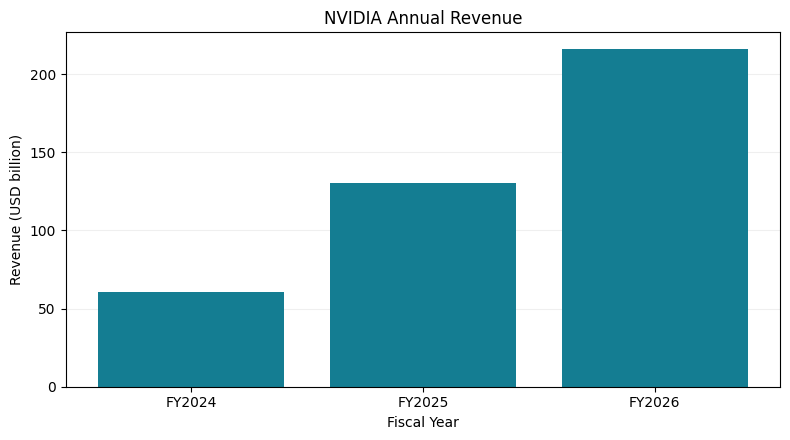

In [5]:
year_labels = "FY" + dataset2["fiscal_year"].astype(str)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(year_labels, dataset2["Total Revenue ($B)"], color="#147D92")
ax.set(xlabel="Fiscal Year", ylabel="Revenue (USD billion)", title="NVIDIA Annual Revenue")
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## 6. Operating-margin line chart
Fixed: one margin chart instead of duplicate cells. A zero-based percentage scale makes the absolute changes clear.

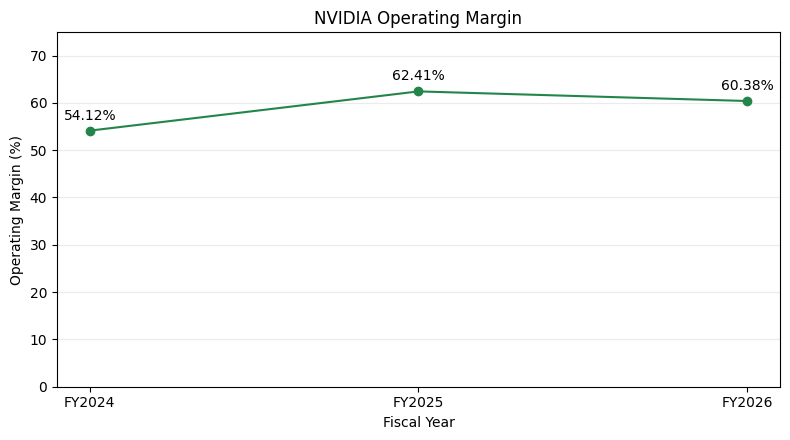

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(year_labels, dataset2["calculated_operating_margin"], marker="o", color="#24854B")
for year, margin in zip(year_labels, dataset2["calculated_operating_margin"]):
    ax.annotate(f"{margin:.2f}%", (year, margin), xytext=(0, 8),
                textcoords="offset points", ha="center")
ax.set(xlabel="Fiscal Year", ylabel="Operating Margin (%)", title="NVIDIA Operating Margin")
ax.set_ylim(0, max(1, dataset2["calculated_operating_margin"].max()) * 1.2)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

## 7. NEW: set your first forecast assumptions

**Practice assumptions only—not researched NVIDIA forecasts:**
- Revenue growth: 20%.
- Operating margin: 58%.

Change the values below and rerun from this section. Enter `0.20` for 20%, not `20`.
Historical observations remain unchanged. The forecast uses the latest historical year, so the supplied FY2026 dataset produces an FY2027 forecast.

In [7]:
assumed_growth = 0.20
assumed_operating_margin = 0.58

if not np.isfinite(assumed_growth) or assumed_growth <= -1:
    raise ValueError("Growth must be finite and greater than -100%.")
if not np.isfinite(assumed_operating_margin) or not -1 <= assumed_operating_margin <= 1:
    raise ValueError("For this learning model, enter a margin between -1 and 1.")

base_row = dataset2.iloc[-1]
base_year = int(base_row["fiscal_year"])
base_revenue = float(base_row["Total Revenue ($B)"])
forecast_year = base_year + 1

## 8. NEW: calculate forecast revenue and operating income

Revenue = base revenue × (1 + growth).  
Operating income = forecast revenue × assumed operating margin.

A separate `forecast_table` keeps assumptions and projections out of the historical table.

In [8]:
forecast_revenue = base_revenue * (1 + assumed_growth)
forecast_operating_income = forecast_revenue * assumed_operating_margin

forecast_table = pd.DataFrame([{
    "Fiscal Year": f"FY{forecast_year}",
    "Status": "Illustrative forecast",
    "Assumed Revenue Growth (%)": assumed_growth * 100,
    "Forecast Revenue ($B)": forecast_revenue,
    "Assumed Operating Margin (%)": assumed_operating_margin * 100,
    "Forecast Operating Income ($B)": forecast_operating_income,
}])
display(forecast_table.round(3))
print(f"FY{forecast_year} revenue: ${forecast_revenue:,.3f} billion")
print(f"FY{forecast_year} operating income: ${forecast_operating_income:,.5f} billion")
print("Practice assumptions only; this is not an investment recommendation.")

,Fiscal Year,Status,Assumed Revenue Growth (%),Forecast Revenue ($B),Assumed Operating Margin (%),Forecast Operating Income ($B)
0,FY2027,Illustrative forecast,20.00,259.13,58.00,150.29


FY2027 revenue: $259.128 billion
FY2027 operating income: $150.29424 billion
Practice assumptions only; this is not an investment recommendation.


## 9. Quick checks
The worked example should give 259.128 and 150.29424 USD billion. These checks distinguish arithmetic errors from rounding differences. If you change inputs, the default-example check is skipped.

In [9]:
assert pd.isna(dataset2.iloc[0]["calculated_revenue_growth"])
assert len(forecast_table) == 1
assert forecast_year == base_year + 1
assert np.isclose(forecast_operating_income, forecast_revenue * assumed_operating_margin)

if (base_year == 2026 and np.isclose(base_revenue, 215.94)
        and np.isclose(assumed_growth, 0.20)
        and np.isclose(assumed_operating_margin, 0.58)):
    assert np.isclose(forecast_revenue, 259.128)
    assert np.isclose(forecast_operating_income, 150.29424)
    print("Default example verified: revenue 259.128; operating income 150.29424 ($B).")
else:
    print("Custom inputs: calculation consistency checks passed.")

Default example verified: revenue 259.128; operating income 150.29424 ($B).


In [10]:
growth_rate = [0.20,0.15,0.12,0.10,0.08]
print(growth_rate)

[0.2, 0.15, 0.12, 0.1, 0.08]


In [11]:
previous_revenue = dataset2["Total Revenue ($B)"].iloc[-1]
print(previous_revenue)

215.94


In [12]:
forcast_rows = []
print(forcast_rows)

[]


In [13]:
growth = growth_rate[0]
forcasted_revenue = previous_revenue * (1 + growth)
print(forcasted_revenue)

259.128


In [22]:
year_result = {
    "Fiscal Year": 2027,
    "Growth %": growth * 100,
    "Revenue ($B)": forecast_revenue}
forcast_rows.append(year_result)
print(forcast_rows)

[{'Fiscal Year': 2027, 'Growth %': 20.0, 'Revenue ($B)': 259.128}]


In [23]:
previous_revenue = forecast_revenue

print(previous_revenue)

259.128


In [24]:
growth = growth_rate[1]
forcasted_revenue = previous_revenue * (1 + growth)
print(forcasted_revenue)

297.99719999999996


In [25]:
year_result = {
    "Fiscal Year":2028,
    "Growth (%)": growth * 100,
    "Revenue ($B)": forecast_revenue}
forcast_rows.append(year_result)
print(forcast_rows)

[{'Fiscal Year': 2027, 'Growth %': 20.0, 'Revenue ($B)': 259.128}, {'Fiscal Year': 2028, 'Growth (%)': 15.0, 'Revenue ($B)': 259.128}]


In [31]:
growth_rates = [0.20, 0.15, 0.12, 0.10, 0.08]

previous_revenue = dataset2["Total Revenue ($B)"].iloc[-1]
forecast_rows = []
year = 2027

for growth in growth_rates:
    forecast_revenue = previous_revenue * (1 + growth)

    year_result = {
        "Fiscal Year": year,
        "Growth (%)": growth * 100,
        "Revenue ($B)": forecast_revenue
    }

    forecast_rows.append(year_result)

    previous_revenue = forecast_revenue
    year = year + 1

display(pd.DataFrame(forecast_rows).round(3))

,Fiscal Year,Growth (%),Revenue ($B)
0,2027,20.00,259.13
1,2028,15.00,298.00
2,2029,12.00,333.76
3,2030,10.00,367.13
4,2031,8.00,396.50


In [32]:
print(len(forecast_rows))
print(forecast_rows)

5
[{'Fiscal Year': 2027, 'Growth (%)': 20.0, 'Revenue ($B)': np.float64(259.128)}, {'Fiscal Year': 2028, 'Growth (%)': 15.0, 'Revenue ($B)': np.float64(297.99719999999996)}, {'Fiscal Year': 2029, 'Growth (%)': 12.0, 'Revenue ($B)': np.float64(333.756864)}, {'Fiscal Year': 2030, 'Growth (%)': 10.0, 'Revenue ($B)': np.float64(367.1325504)}, {'Fiscal Year': 2031, 'Growth (%)': 8.0, 'Revenue ($B)': np.float64(396.50315443200003)}]


In [33]:
forecast_table = pd.DataFrame(forecast_rows)
display(forecast_table.round(3))

,Fiscal Year,Growth (%),Revenue ($B)
0,2027,20.00,259.13
1,2028,15.00,298.00
2,2029,12.00,333.76
3,2030,10.00,367.13
4,2031,8.00,396.50


In [37]:
operation_margin = [0.58,0.58,0.58,0.58,0.58]
print(operation_margin)
forecast_table['Operating Margin (%)'] = operation_margin
display(forecast_table.round(3))

[0.58, 0.58, 0.58, 0.58, 0.58]


,Fiscal Year,Growth (%),Revenue ($B),Operating Margin (%)
0,2027,20.00,259.13,0.58
1,2028,15.00,298.00,0.58
2,2029,12.00,333.76,0.58
3,2030,10.00,367.13,0.58
4,2031,8.00,396.50,0.58


In [38]:
forecast_table["Operating Income ($B)"] = forecast_table["Revenue ($B)"] * forecast_table["Operating Margin (%)"]
display(forecast_table.round(3))

,Fiscal Year,Growth (%),Revenue ($B),Operating Margin (%),Operating Income ($B)
0,2027,20.00,259.13,0.58,150.29
1,2028,15.00,298.00,0.58,172.84
2,2029,12.00,333.76,0.58,193.58
3,2030,10.00,367.13,0.58,212.94
4,2031,8.00,396.50,0.58,229.97


In [41]:
# 1. Create the missing column: 58% as a decimal
# This is a practice assumption for every forecast year.
forecast_table["Operating Margin"] = 0.58

# 2. Calculate operating income
forecast_table["Operating Income ($B)"] = (
    forecast_table["Revenue ($B)"]
    * forecast_table["Operating Margin"]
)

# 3. Convert decimal margin to percentage for display
forecast_table["Operating Margin (%)"] = (
    forecast_table["Operating Margin"] * 100
)

# 4. Display the selected columns
display_columns = [
    "Fiscal Year",
    "Growth (%)",
    "Revenue ($B)",
    "Operating Margin (%)",
    "Operating Income ($B)"
]

display(forecast_table[display_columns].round(3))

,Fiscal Year,Growth (%),Revenue ($B),Operating Margin (%),Operating Income ($B)
0,2027,20.00,259.13,58.00,150.29
1,2028,15.00,298.00,58.00,172.84
2,2029,12.00,333.76,58.00,193.58
3,2030,10.00,367.13,58.00,212.94
4,2031,8.00,396.50,58.00,229.97


In [42]:
expected_revenue = 215.94*1.20
expected_operating_income = expected_revenue * 0.50
print("Manual revenue:",expected_revenue)
print("Table revenue:",forecast_table["Revenue ($B)"].iloc[0])
print("Manual operating income:",expected_operating_income)
print("Table operating income:",forecast_table["Operating Income ($B)"].iloc[0])

Manual revenue: 259.128
Table revenue: 259.128
Manual operating income: 129.564
Table operating income: 150.29423999999997


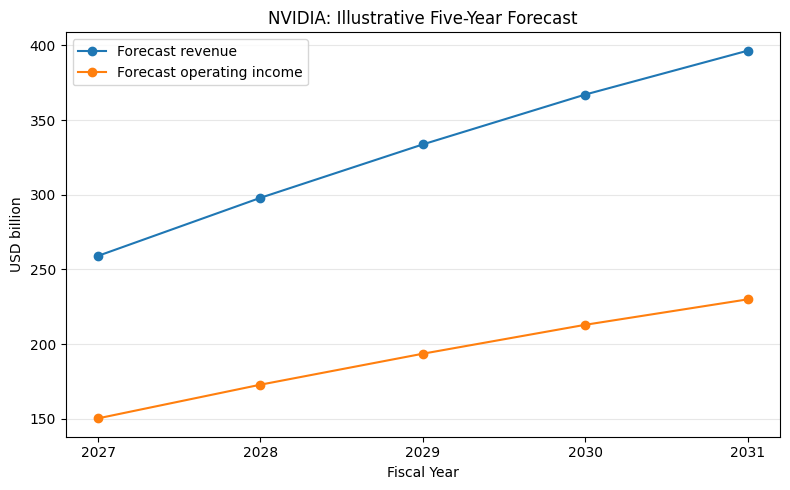

In [43]:
import matplotlib.pyplot as plt

year_labels = forecast_table["Fiscal Year"].astype(str)

plt.figure(figsize=(8, 5))

plt.plot(
    year_labels,
    forecast_table["Revenue ($B)"],
    marker="o",
    label="Forecast revenue"
)

plt.plot(
    year_labels,
    forecast_table["Operating Income ($B)"],
    marker="o",
    label="Forecast operating income"
)

plt.xlabel("Fiscal Year")
plt.ylabel("USD billion")
plt.title("NVIDIA: Illustrative Five-Year Forecast")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
forecast_table[display_columns].to_csv(
    "NVIDIA_five_year_forecast.csv",
    index=False
)

In [45]:
assumed_tax_rate = 0.25

forecast_table["Operating Tax Rate (%)"] = assumed_tax_rate * 100

forecast_table["NOPAT ($B)"] = (
    forecast_table["Operating Income ($B)"]
    * (1 - assumed_tax_rate)
)

display(
    forecast_table[
        [
            "Fiscal Year",
            "Operating Income ($B)",
            "Operating Tax Rate (%)",
            "NOPAT ($B)"
        ]
    ].round(3)
)

,Fiscal Year,Operating Income ($B),Operating Tax Rate (%),NOPAT ($B)
0,2027,150.29,25.00,112.72
1,2028,172.84,25.00,129.63
2,2029,193.58,25.00,145.18
3,2030,212.94,25.00,159.70
4,2031,229.97,25.00,172.48


In [46]:
required_columns = [
    "Fiscal Year",
    "Revenue ($B)",
    "Operating Income ($B)"
]

for column in required_columns:
    if column not in forecast_table.columns:
        raise ValueError(f"Missing column: {column}")

display(forecast_table[required_columns].round(3))

,Fiscal Year,Revenue ($B),Operating Income ($B)
0,2027,259.13,150.29
1,2028,298.00,172.84
2,2029,333.76,193.58
3,2030,367.13,212.94
4,2031,396.50,229.97


In [47]:
valuation_table = forecast_table.copy(deep=True)
valuation_table = (
    valuation_table
    .sort_values("Fiscal Year")
    .reset_index(drop=True)
)

In [52]:
assumptions = {
"tax_rate": 0.25,
"da_ratio": 0.03,
"capex_ratio": 0.05,
"nwc_ratio": 0.10,
"wacc":0.10,
"terminal_growth":0.03
}
display(pd.Series(assumptions,name="Decimal assumption"))

tax_rate          0.25
da_ratio          0.03
capex_ratio       0.05
nwc_ratio         0.10
wacc              0.10
terminal_growth   0.03
Name: Decimal assumption, dtype: float64

In [53]:
valuation_table["NOPAT ($B)"] = (
    valuation_table["Operating Income ($B)"]
    * (1 - assumptions["tax_rate"])
)

display(
    valuation_table[
        ["Fiscal Year", "Operating Income ($B)", "NOPAT ($B)"]
    ].round(3)
)

,Fiscal Year,Operating Income ($B),NOPAT ($B)
0,2027,150.29,112.72
1,2028,172.84,129.63
2,2029,193.58,145.18
3,2030,212.94,159.70
4,2031,229.97,172.48


In [54]:
valuation_table["D&A ($B)"] = (
    valuation_table["Revenue ($B)"]
    * assumptions["da_ratio"]
)

display(
    valuation_table[
        ["Fiscal Year", "Revenue ($B)", "D&A ($B)"]
    ].round(3)
)

,Fiscal Year,Revenue ($B),D&A ($B)
0,2027,259.13,7.77
1,2028,298.00,8.94
2,2029,333.76,10.01
3,2030,367.13,11.01
4,2031,396.50,11.89


In [55]:
valuation_table["Capex ($B)"] = (
    valuation_table["Revenue ($B)"]
    * assumptions["capex_ratio"]
)

display(
    valuation_table[
        ["Fiscal Year", "D&A ($B)", "Capex ($B)"]
    ].round(3)
)

,Fiscal Year,D&A ($B),Capex ($B)
0,2027,7.77,12.96
1,2028,8.94,14.90
2,2029,10.01,16.69
3,2030,11.01,18.36
4,2031,11.89,19.82


In [56]:
valuation_table["Operating NWC ($B)"] = (
    valuation_table["Revenue ($B)"]
    * assumptions["nwc_ratio"]
)

display(
    valuation_table[
        ["Fiscal Year", "Revenue ($B)", "Operating NWC ($B)"]
    ].round(3)
)

,Fiscal Year,Revenue ($B),Operating NWC ($B)
0,2027,259.13,25.91
1,2028,298.00,29.80
2,2029,333.76,33.38
3,2030,367.13,36.71
4,2031,396.50,39.65


In [57]:
base_revenue = float(
    dataset2["Total Revenue ($B)"].iloc[-1]
)

base_nwc = base_revenue * assumptions["nwc_ratio"]

print("Practice opening NWC ($B):", base_nwc)

Practice opening NWC ($B): 21.594


In [58]:
valuation_table["Change in NWC ($B)"] = (
    valuation_table["Operating NWC ($B)"].diff()
)

first_index = valuation_table.index[0]

valuation_table.loc[first_index, "Change in NWC ($B)"] = (
    valuation_table.loc[first_index, "Operating NWC ($B)"]
    - base_nwc
)

display(
    valuation_table[
        ["Fiscal Year", "Operating NWC ($B)", "Change in NWC ($B)"]
    ].round(3)
)

,Fiscal Year,Operating NWC ($B),Change in NWC ($B)
0,2027,25.91,4.32
1,2028,29.80,3.89
2,2029,33.38,3.58
3,2030,36.71,3.34
4,2031,39.65,2.94


In [59]:
valuation_table["FCFF ($B)"] = (
    valuation_table["NOPAT ($B)"]
    + valuation_table["D&A ($B)"]
    - valuation_table["Capex ($B)"]
    - valuation_table["Change in NWC ($B)"]
)

fcff_columns = [
    "Fiscal Year",
    "NOPAT ($B)",
    "D&A ($B)",
    "Capex ($B)",
    "Change in NWC ($B)",
    "FCFF ($B)"
]

display(valuation_table[fcff_columns].round(3))

,Fiscal Year,NOPAT ($B),D&A ($B),Capex ($B),Change in NWC ($B),FCFF ($B)
0,2027,112.72,7.77,12.96,4.32,103.22
1,2028,129.63,8.94,14.90,3.89,119.78
2,2029,145.18,10.01,16.69,3.58,134.93
3,2030,159.70,11.01,18.36,3.34,149.02
4,2031,172.48,11.89,19.82,2.94,161.61


In [60]:
wacc = assumptions["wacc"]
terminal_growth = assumptions["terminal_growth"]

if wacc <= 0:
    raise ValueError("This practice model requires a positive WACC.")

if terminal_growth < 0:
    raise ValueError("This practice example uses non-negative terminal growth.")

if wacc <= terminal_growth:
    raise ValueError("WACC must be greater than terminal growth.")

valuation_table["Period"] = range(
    1, len(valuation_table) + 1
)

display(
    valuation_table[["Fiscal Year", "Period", "FCFF ($B)"]]
)

,Fiscal Year,Period,FCFF ($B)
0,2027,1,103.22
1,2028,2,119.78
2,2029,3,134.93
3,2030,4,149.02
4,2031,5,161.61


In [61]:
valuation_table["Discount Factor"] = (
    1 / (1 + wacc) ** valuation_table["Period"]
)

valuation_table["PV of FCFF ($B)"] = (
    valuation_table["FCFF ($B)"]
    * valuation_table["Discount Factor"]
)

pv_forecast = valuation_table["PV of FCFF ($B)"].sum()

display(
    valuation_table[
        [
            "Fiscal Year",
            "FCFF ($B)",
            "Discount Factor",
            "PV of FCFF ($B)"
        ]
    ].round(4)
)

print("Present value of forecast FCFF ($B):", round(pv_forecast, 3))

,Fiscal Year,FCFF ($B),Discount Factor,PV of FCFF ($B)
0,2027,103.22,0.91,93.84
1,2028,119.78,0.83,98.99
2,2029,134.93,0.75,101.38
3,2030,149.02,0.68,101.78
4,2031,161.61,0.62,100.35


Present value of forecast FCFF ($B): 496.339


In [62]:
last_row = valuation_table.iloc[-1]

terminal_margin = 0.58  # Fictional stable operating-margin assumption

terminal_revenue = (
    last_row["Revenue ($B)"] * (1 + terminal_growth)
)

terminal_operating_income = terminal_revenue * terminal_margin

terminal_nopat = (
    terminal_operating_income * (1 - assumptions["tax_rate"])
)

terminal_da = terminal_revenue * assumptions["da_ratio"]
terminal_capex = terminal_revenue * assumptions["capex_ratio"]
terminal_nwc = terminal_revenue * assumptions["nwc_ratio"]

terminal_change_nwc = (
    terminal_nwc - last_row["Operating NWC ($B)"]
)

terminal_fcff = (
    terminal_nopat
    + terminal_da
    - terminal_capex
    - terminal_change_nwc
)

print("Terminal-year FCFF ($B):", round(terminal_fcff, 3))

Terminal-year FCFF ($B): 168.296


In [63]:
number_of_years = len(valuation_table)

terminal_value = terminal_fcff / (wacc - terminal_growth)

pv_terminal_value = (
    terminal_value / (1 + wacc) ** number_of_years
)

enterprise_value = pv_forecast + pv_terminal_value

print("Terminal value at end of forecast ($B):", round(terminal_value, 3))
print("Present value of terminal value ($B):", round(pv_terminal_value, 3))
print("Operating enterprise value ($B):", round(enterprise_value, 3))

Terminal value at end of forecast ($B): 2404.225
Present value of terminal value ($B): 1492.835
Operating enterprise value ($B): 1989.174


In [64]:
practice_excess_cash_b = 10.0
practice_debt_b = 5.0
practice_shares_b = 20.0

if practice_shares_b <= 0:
    raise ValueError("Shares must be greater than zero.")

equity_value = (
    enterprise_value
    + practice_excess_cash_b
    - practice_debt_b
)

practice_value_per_share = equity_value / practice_shares_b

print("Practice equity value ($B):", round(equity_value, 3))
print("Practice value per share ($):", round(practice_value_per_share, 2))
print("Illustrative output only — not a verified NVIDIA valuation.")

Practice equity value ($B): 1994.174
Practice value per share ($): 99.71
Illustrative output only — not a verified NVIDIA valuation.


In [65]:
valuation_summary = pd.DataFrame({
    "Component": [
        "PV of forecast FCFF ($B)",
        "PV of terminal value ($B)",
        "Operating enterprise value ($B)",
        "Practice excess cash ($B)",
        "Practice debt ($B)",
        "Practice equity value ($B)",
        "Practice shares (billions)",
        "Practice value per share ($)"
    ],
    "Value": [
        pv_forecast,
        pv_terminal_value,
        enterprise_value,
        practice_excess_cash_b,
        practice_debt_b,
        equity_value,
        practice_shares_b,
        practice_value_per_share
    ]
})

display(valuation_summary.round(3))

if enterprise_value > 0:
    terminal_contribution = (
        pv_terminal_value / enterprise_value * 100
    )
    print("Terminal contribution (%):", round(terminal_contribution, 2))
else:
    print("Terminal contribution is not meaningful for non-positive enterprise value.")

,Component,Value
0,PV of forecast FCFF ($B),496.34
1,PV of terminal value ($B),"1,492.84"
2,Operating enterprise value ($B),"1,989.17"
3,Practice excess cash ($B),10.00
4,Practice debt ($B),5.00
5,Practice equity value ($B),"1,994.17"
6,Practice shares (billions),20.00
7,Practice value per share ($),99.71


Terminal contribution (%): 75.05


In [66]:
first = valuation_table.iloc[0]

fcff_with_extra_capex = (
    first["NOPAT ($B)"]
    + first["D&A ($B)"]
    - (first["Capex ($B)"] + 1)
    - first["Change in NWC ($B)"]
)

difference = first["FCFF ($B)"] - fcff_with_extra_capex

print("FCFF decrease when capex rises by $1B:", round(difference, 6))

FCFF decrease when capex rises by $1B: 1.0


In [69]:
import math

def calculate_nopat(operating_income, tax_rate):
    if not math.isfinite(operating_income):
        raise ValueError("Operating income must be a finite number.")

    if not math.isfinite(tax_rate) or not 0 <= tax_rate <= 1:
        raise ValueError("Tax rate decimal mein enter karo: 0.25 for 25%.")

    if operating_income < 0:
        raise ValueError(
            "This simple model does not handle operating losses yet."
        )

    return operating_income * (1 - tax_rate)

In [70]:
result = calculate_nopat(100,0.25)
print(result)

75.0


In [72]:
import pandas as pd

def run_valuation(
    base_revenue,
    base_nwc,
    start_year,
    growth_rates,
    margins,
    tax_rate,
    da_ratio,
    capex_ratio,
    nwc_ratio,
    wacc,
    terminal_growth,
    terminal_margin,
    excess_cash,
    debt,
    shares
):
    # 1. Validate inputs
    if len(growth_rates) == 0 or len(growth_rates) != len(margins):
        raise ValueError("Growth aur margin lists ki equal, non-zero length chahiye.")

    all_numbers = [
        base_revenue, base_nwc, tax_rate,
        da_ratio, capex_ratio, nwc_ratio,
        wacc, terminal_growth, terminal_margin,
        excess_cash, debt, shares,
        *growth_rates, *margins
    ]

    if not all(math.isfinite(value) for value in all_numbers):
        raise ValueError("All inputs must be finite numbers.")

    if base_revenue <= 0 or shares <= 0:
        raise ValueError("Base revenue aur shares positive hone chahiye.")

    if not 0 <= tax_rate <= 1:
        raise ValueError("Tax rate 0 aur 1 ke beech hona chahiye.")

    if any(growth <= -1 for growth in growth_rates):
        raise ValueError("Growth must be greater than -100%.")

    if any(not 0 <= margin <= 1 for margin in margins):
        raise ValueError("This practice model supports margins from 0 to 1.")

    if not 0 <= terminal_margin <= 1:
        raise ValueError("Terminal margin must be between 0 and 1.")

    if da_ratio < 0 or capex_ratio < 0:
        raise ValueError("D&A aur capex ratios negative nahi hone chahiye.")

    if excess_cash < 0 or debt < 0:
        raise ValueError("Enter cash aur debt as non-negative amounts.")

    if wacc <= 0 or terminal_growth < 0 or wacc <= terminal_growth:
        raise ValueError("Require WACC > terminal growth >= 0.")

    # 2. Start from historical balances
    previous_revenue = base_revenue
    previous_nwc = base_nwc
    rows = []

    # 3. Forecast each year
    for period, (growth, margin) in enumerate(
        zip(growth_rates, margins), start=1
    ):
        revenue = previous_revenue * (1 + growth)
        operating_income = revenue * margin

        nopat = calculate_nopat(operating_income, tax_rate)

        da = revenue * da_ratio
        capex = revenue * capex_ratio
        nwc = revenue * nwc_ratio
        change_nwc = nwc - previous_nwc

        fcff = nopat + da - capex - change_nwc
        pv_fcff = fcff / (1 + wacc) ** period

        rows.append({
            "Fiscal Year": start_year + period - 1,
            "Period": period,
            "Revenue ($B)": revenue,
            "Operating Margin (%)": margin * 100,
            "Operating Income ($B)": operating_income,
            "NOPAT ($B)": nopat,
            "D&A ($B)": da,
            "Capex ($B)": capex,
            "Operating NWC ($B)": nwc,
            "Change in NWC ($B)": change_nwc,
            "FCFF ($B)": fcff,
            "PV of FCFF ($B)": pv_fcff
        })

        previous_revenue = revenue
        previous_nwc = nwc

    forecast = pd.DataFrame(rows)

    # 4. Rebuild a stable terminal-year cash flow
    terminal_revenue = previous_revenue * (1 + terminal_growth)

    terminal_nopat = calculate_nopat(
        terminal_revenue * terminal_margin,
        tax_rate
    )

    terminal_da = terminal_revenue * da_ratio
    terminal_capex = terminal_revenue * capex_ratio
    terminal_nwc = terminal_revenue * nwc_ratio

    terminal_fcff = (
        terminal_nopat
        + terminal_da
        - terminal_capex
        - (terminal_nwc - previous_nwc)
    )

    if terminal_fcff <= 0:
        raise ValueError(
            "This practice terminal model requires positive stable FCFF."
        )

    # 5. Calculate enterprise and equity value
    terminal_value = terminal_fcff / (wacc - terminal_growth)

    pv_terminal = terminal_value / (1 + wacc) ** len(rows)
    pv_forecast = forecast["PV of FCFF ($B)"].sum()

    enterprise_value = pv_forecast + pv_terminal
    equity_value = enterprise_value + excess_cash - debt

    # Negative equity needs further interpretation.
    value_per_share = (
        equity_value / shares if equity_value > 0 else None
    )

    return {
        "forecast": forecast,
        "pv_forecast": pv_forecast,
        "terminal_fcff": terminal_fcff,
        "pv_terminal": pv_terminal,
        "enterprise_value": enterprise_value,
        "equity_value": equity_value,
        "value_per_share": value_per_share
    }

In [73]:
base_inputs = {
    "base_revenue": float(
        dataset2["Total Revenue ($B)"].iloc[-1]
    ),
    "base_nwc": float(
        dataset2["Total Revenue ($B)"].iloc[-1]
    ) * 0.10,

    "start_year": 2027,
    "growth_rates": [0.20, 0.15, 0.12, 0.10, 0.08],
    "margins": [0.58, 0.58, 0.58, 0.58, 0.58],

    "tax_rate": 0.25,
    "da_ratio": 0.03,
    "capex_ratio": 0.05,
    "nwc_ratio": 0.10,

    "wacc": 0.10,
    "terminal_growth": 0.03,
    "terminal_margin": 0.58,

    "excess_cash": 10.0,
    "debt": 5.0,
    "shares": 20.0
}

base_result = run_valuation(**base_inputs)

display(base_result["forecast"].round(3))

print(
    "Practice value per share:",
    base_result["value_per_share"]
)

,Fiscal Year,Period,Revenue ($B),Operating Margin (%),Operating Income ($B),NOPAT ($B),D&A ($B),Capex ($B),Operating NWC ($B),Change in NWC ($B),FCFF ($B),PV of FCFF ($B)
0,2027,1,259.13,58.00,150.29,112.72,7.77,12.96,25.91,4.32,103.22,93.84
1,2028,2,298.00,58.00,172.84,129.63,8.94,14.90,29.80,3.89,119.78,98.99
2,2029,3,333.76,58.00,193.58,145.18,10.01,16.69,33.38,3.58,134.93,101.38
3,2030,4,367.13,58.00,212.94,159.70,11.01,18.36,36.71,3.34,149.02,101.78
4,2031,5,396.50,58.00,229.97,172.48,11.89,19.82,39.65,2.94,161.61,100.35


Practice value per share: 99.70867644955942


In [74]:
bear_inputs = base_inputs.copy()

bear_inputs.update({
    "growth_rates": [0.10, 0.08, 0.06, 0.05, 0.04],
    "margins": [0.50, 0.50, 0.51, 0.51, 0.52],
    "capex_ratio": 0.05,
    "nwc_ratio": 0.12,
    "terminal_margin": 0.52
})

bull_inputs = base_inputs.copy()

bull_inputs.update({
    "growth_rates": [0.25, 0.20, 0.16, 0.12, 0.10],
    "margins": [0.60, 0.60, 0.61, 0.61, 0.62],
    "capex_ratio": 0.06,
    "nwc_ratio": 0.11,
    "terminal_margin": 0.62
})

scenario_inputs = {
    "Bear": bear_inputs,
    "Base": base_inputs,
    "Bull": bull_inputs
}

In [75]:
scenario_results = {}
scenario_rows = []

for scenario_name, inputs in scenario_inputs.items():
    result = run_valuation(**inputs)

    scenario_results[scenario_name] = result

    scenario_rows.append({
        "Scenario": scenario_name,
        "Enterprise Value ($B)": result["enterprise_value"],
        "Equity Value ($B)": result["equity_value"],
        "Practice Value per Share ($)": result["value_per_share"]
    })

scenario_table = pd.DataFrame(scenario_rows)

display(scenario_table.round(2))

,Scenario,Enterprise Value ($B),Equity Value ($B),Practice Value per Share ($)
0,Bear,"1,347.72","1,352.72",67.64
1,Base,"1,989.17","1,994.17",99.71
2,Bull,"2,387.46","2,392.46",119.62


In [76]:
wacc_values = [0.08, 0.10, 0.12]
terminal_growth_values = [0.01, 0.02, 0.03]

sensitivity_table = pd.DataFrame(
    index=[f"{rate:.0%}" for rate in wacc_values],
    columns=[f"{growth:.0%}" for growth in terminal_growth_values],
    dtype=float
)

for rate in wacc_values:
    for growth in terminal_growth_values:
        if rate <= growth:
            continue

        sensitivity_inputs = base_inputs.copy()

        sensitivity_inputs["wacc"] = rate
        sensitivity_inputs["terminal_growth"] = growth

        result = run_valuation(**sensitivity_inputs)

        sensitivity_table.loc[
            f"{rate:.0%}",
            f"{growth:.0%}"
        ] = result["value_per_share"]

sensitivity_table.index.name = "WACC"
sensitivity_table.columns.name = "Terminal growth"

display(sensitivity_table.round(2))

Terminal growth,1%,2%,3%
WACC,,,
8%,107.09,121.24,141.03
10%,82.26,89.89,99.71
12%,66.52,71.15,76.81


In [77]:
sensitivity_base_value = sensitivity_table.loc["10%", "3%"]

print("Base valuation:", base_result["value_per_share"])
print("Matching sensitivity cell:", sensitivity_base_value)

Base valuation: 99.70867644955942
Matching sensitivity cell: 99.70867644955942


In [78]:
peer_table = pd.DataFrame({
    "Company": ["Demo Peer A", "Demo Peer B", "Demo Peer C"],
    "Share Price ($)": [90.0, 144.0, 240.0],
    "EPS ($)": [6.0, 8.0, 10.0]
})

display(peer_table)

,Company,Share Price ($),EPS ($)
0,Demo Peer A,90.00,6.00
1,Demo Peer B,144.00,8.00
2,Demo Peer C,240.00,10.00


In [79]:
peer_table["P/E"] = float("nan")

valid_peers = (
    (peer_table["EPS ($)"] > 0)
    & (peer_table["Share Price ($)"] > 0)
)

peer_table.loc[valid_peers, "P/E"] = (
    peer_table.loc[valid_peers, "Share Price ($)"]
    / peer_table.loc[valid_peers, "EPS ($)"]
)

display(peer_table.round(2))

,Company,Share Price ($),EPS ($),P/E
0,Demo Peer A,90.00,6.00,15.00
1,Demo Peer B,144.00,8.00,18.00
2,Demo Peer C,240.00,10.00,24.00


In [80]:
if peer_table["P/E"].notna().sum() == 0:
    raise ValueError("No valid peer multiples available.")

median_pe = peer_table["P/E"].median()

print("Median peer P/E:", median_pe)

Median peer P/E: 18.0


In [81]:
practice_target_eps = 10.0

peer_implied_value = median_pe * practice_target_eps

print("Fictional target EPS:", practice_target_eps)
print("Peer-implied value per share:", peer_implied_value)

Fictional target EPS: 10.0
Peer-implied value per share: 180.0
